In [1]:
import scvelo as scv
#import dynamo as dyn
import numpy as np
from anndata import AnnData
# import loompy
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.cluster.hierarchy import fcluster,leaders,dendrogram,linkage
from sklearn.decomposition import PCA
from scipy.linalg import inv
from sklearn.mixture import GaussianMixture
from RKHS import SparseVFC
from RKHS import Jacobian_rkhs_gaussian
from scipy.stats import multivariate_normal
from scipy.sparse import csr_matrix
import pandas as pd

print(scv.__version__)

0.2.5


Curvature:
$k(x,y) = 1 - \frac{W(x,y)}{d(x,y)}$

$X \sim N(\mu_1,\sigma_1^2),Y \sim N(\mu_2,\sigma_2^2)$. $\quad \quad$

$W_1$:$\quad$ $d(x,y)$ is $L_1$ distance to enable dimension-wise computation and summation of the W₁ distance in higher dimensions (with diagonal covariance matrices)

$\quad$
  $W_1(X,Y)$
  $= |b|\sqrt{\frac{2}{\pi}}\,$
  $\exp\!\left(-\frac{a^2}{2b^2}\right)$
  $+ a\,\operatorname{erf}\!\left(\frac{a}{\sqrt{2}\,|b|}\right),$
  $\quad a = \mu_1 - \mu_2,\; b = \sigma_1 - \sigma_2.$

$\quad$ where 
$\operatorname{erf}(x) = \frac{2}{\sqrt{\pi}} \int_0^x e^{-t^2}\,dt.$

$W_1$:$\quad$ $d(x,y)$ is Euclidean distance

$\quad$ $W_2^2(X, Y)$
$= \|\mu_1 - \mu_2\|_2^2$ 
$+ \operatorname{Tr}\!\Big(\Sigma_1 + \Sigma_2$ 
$- 2\big(\Sigma_2^{1/2}\Sigma_1\Sigma_2^{1/2}\big)^{1/2}\Big).$


In [2]:
import argparse
import random

import scipy.sparse as sp
import scipy.sparse.csgraph
import sklearn.linear_model as sklm
import sklearn.metrics as skm
import sklearn.model_selection as skms
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from ignite.engine import Engine, Events
from ignite.handlers import ModelCheckpoint
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

CHECKPOINT_PREFIX = "g2g"

from g2g_model_Fisher import *
from utils import *
# from minepy import MINE
from sklearn.preprocessing import MinMaxScaler

In [3]:
import seaborn as sns
from GE_utils import *

In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
from scipy.special import erf
def W1_distance(mu1, sigma1, mu2, sigma2):
    """Compute the 1-Wasserstein distance between two Gaussian distributions.
    Args:
        mu1: Mean of the first Gaussian (numpy array).
        sigma1: Covariance matrix of the first Gaussian (numpy array).
        mu2: Mean of the second Gaussian (numpy array).
        sigma2: Covariance matrix of the second Gaussian (numpy array)."""
    mu = np.abs(mu1 - mu2)
    sigma = np.abs(sigma1 - sigma2)
    Wass_dis = sigma * np.sqrt(2/np.pi) * np.exp(-mu**2/(2*sigma**2)) + \
           mu * erf(mu/(np.sqrt(2)*sigma))
    return np.sum(Wass_dis)


### zebrafish

In [6]:
data_path='data/'

#data_name = 'EG_ab_dyn.h5ad'
# data_name = 'EG_ab_bin.h5ad'
data_name = 'zebrafish_dynamo_part.h5ad'
# data_name = 'zebrafish/zebrafish_dynamo_Split_C_6_670_Silhouette_0.6.h5ad'

# data_name = 'DG_bin_ppt.h5ad'
#data_name = 'DentateGyrus/DentateGyrus.loom'
adata0=scv.read(data_path+data_name, cache=True)
[k_nei,K,L] = [10,3,6]
print(f'when K = {K}, recommend k_nei > {int(len(adata0)**(1/K))}:',int(len(adata0)**(1/K))<k_nei)
model_name = 'zebrafish'

subfolder = 'Adjacency'
result_path = 'results/'+model_name+'/'+subfolder+'/'

import os
folder = os.path.exists(result_path)
if not folder:                   #判断是否存在文件夹如果不存在则创建为文件夹
    os.makedirs(result_path)

when K = 3, recommend k_nei > 15: False


In [7]:
scv.pp.pca(adata0,n_comps=50)

## ------data preprocessing: single run
scv.pp.neighbors(adata0, n_neighbors=k_nei)
scv.pp.moments(adata0, n_pcs=50, n_neighbors=k_nei)

computing neighbors


d:\Anaconda\envs\pytorch\Lib\site-packages\pandas\core\algorithms.py:516: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps.dtype], [])


    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [8]:
scv.tl.velocity(adata0)
gene_arr=adata0.var.index.values
X_pca=adata0.obsm['X_pca']
# cell_vpt=adata0.obs['velocity_pseudotime'].values#cell_vpt = adata0.obs['latent_time'].values#
cell_vpt=adata0.obs['Size_Factor'].values
color_label = cell_vpt
Xs=adata0.layers['Ms']#adata.X.A#
X_pca.shape
cell_nei=adata0.uns['neighbors']['indices']
# cell_nei=adata0.obsp['distances'].indices.reshape([-1,k_nei-1])
def Nei_matrices(cell_nei,k_nei,adata):
    global row,col
    row =np.array([np.ones((k_nei,))*i for i in range(adata.shape[0])]).flatten()
    col=cell_nei.flatten()
    w_val=np.array([np.linalg.norm(X_pca[int(i),:]-X_pca[int(j),:]) for i,j in zip(row,col)])
    adj_val=np.ones(col.shape)
    dc=np.amax(w_val)
    nei_w=[]
    rho_arr=[]
    for i in range(cell_nei.shape[0]):
        dij=np.array([np.linalg.norm(X_pca[i,:]-X_pca[int(j),:]) for j in cell_nei[i]])
        rho=np.sum(np.exp(-dij**2/dc**2))
        nei_w.append(np.exp(-dij**2/dc**2)/rho)
        rho_arr.append(rho)
    rho_arr=np.array(rho_arr)/np.amax(rho_arr)
    nei_w=np.array(nei_w)
    A_mat=csr_matrix((adj_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
    W_mat=csr_matrix((w_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
    Nei_mat=csr_matrix((nei_w.flatten(), (row, col)), shape=(adata.shape[0], adata.shape[0]))
    return nei_w,A_mat,W_mat,Nei_mat
nei_w,A_mat,W_mat,Nei_mat = Nei_matrices(cell_nei,k_nei,adata0)
def smooth_func(X_val,cell_nei=cell_nei,nei_w=nei_w):
    X_s=X_val.copy()
    for ci in range(len(X_val)):
        X_s[ci]=np.dot(X_val[cell_nei[ci,:]],nei_w[ci,:])
    return(X_s)


computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


d:\Anaconda\envs\pytorch\Lib\site-packages\scvelo\tools\optimization.py:173: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


In [9]:
[k_nei,K,L] = [10,3,6]
subfolder = 'junda'
read_path = 'results/'+model_name+'/'+subfolder+'/' +f'k_nei={k_nei}/K={K} L={L}'+'/'
# GE_results = np.load(read_path+'GE_results.npz',allow_pickle=True)['arr_0'].item()

In [10]:
encoder = torch.load(read_path+'encoder.pt')
X = Xs
GE_results = Get_GE_results(encoder,X,GE_eigen=None)

In [11]:
mu_learned = GE_results['mu_learned']
sigma_learned = GE_results['sigma_learned']
latent_z = GE_results['latent_z']
Fisher_g = GE_results['Fisher_g']
pMu_pX = GE_results['pMu_pX']
pSgm_pX = GE_results['pSgm_pX']

0.8731039117366655


d:\Anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


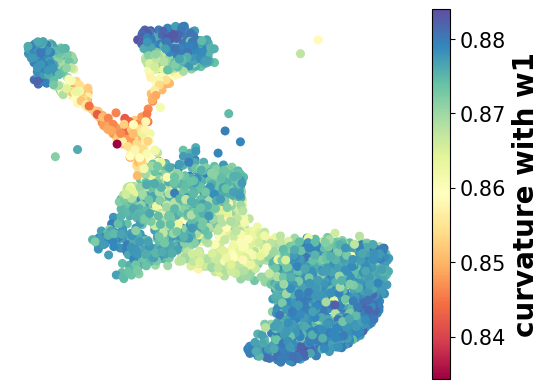

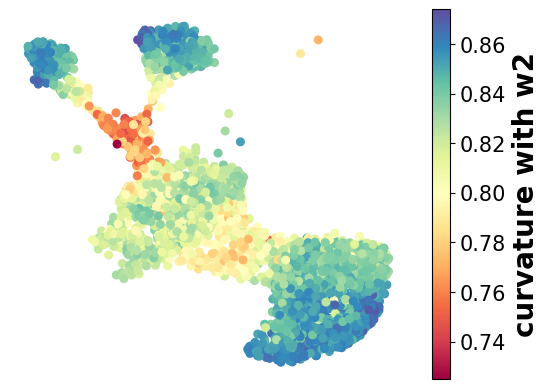

In [12]:
X_plt,Y_plt = adata0.obsm['X_umap'][:,0],adata0.obsm['X_umap'][:,1]
A = csr_matrix(A_mat + np.eye(A_mat.shape[0]))
cRc_arr=[]
cRc_arr_eu=[]
cRc_arr_eu1=[]
for inds in np.split(A.indices, A.indptr)[1:-1]:
    self_ind=inds[0]
    cRc=0
    cRc_eu=0
    cRc_eu1=0
    for nei_k in range(1,len(inds)):
        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dEu1 = np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:],ord=1)
        dWa1 = W1_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dFi=Fisher_dist(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dWa=wasserstein_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        cRc+=1-dWa/dFi
        cRc_eu+=1-dWa/dEu
        cRc_eu1+=1-dWa1/dEu1
    
    cRc_arr.append(cRc/len(inds))
    cRc_arr_eu.append(cRc_eu/len(inds))
    cRc_arr_eu1.append(cRc_eu1/len(inds))

crc = np.array(cRc_arr)
crc_eu = np.array(cRc_arr_eu)
crc_smooth = smooth_func(crc_eu)
crc_eu1 = np.array(cRc_arr_eu1)
crc_smooth1 = smooth_func(crc_eu1)
print(np.corrcoef(crc_smooth,crc_smooth1)[0,1])

idx = ~np.isnan(crc_smooth1)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth1[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature with w1',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)
plt.savefig(f'results/curvature/{data_name}_curvature_w1.png',dpi=600)
plt.show()

idx = ~np.isnan(crc_smooth)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature with w2',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)
plt.savefig(f'results/curvature/{data_name}_curvature_w2.png',dpi=600)
plt.show()

### DG

In [13]:
data_path='data/'

#data_name = 'EG_ab_dyn.h5ad'
# data_name = 'EG_ab_bin.h5ad'
data_name = 'DG_bin_ppt.h5ad'
#data_name = 'DentateGyrus/DentateGyrus.loom'
adata0=scv.read(data_path+data_name, cache=True)
[k_nei,K,L] = [10,2,10]
print(f'when K = {K}, recommend k_nei > {int(len(adata0)**(1/K))}:',int(len(adata0)**(1/K))<k_nei)
model_name = 'DG_bin_ppt'

subfolder = 'Adjacency'
result_path = 'results/'+model_name+'/'+subfolder+'/'

import os
folder = os.path.exists(result_path)
if not folder:                   #判断是否存在文件夹如果不存在则创建为文件夹
    os.makedirs(result_path)

when K = 2, recommend k_nei > 56: False


saving figure to file results/DG_bin_ppt/Adjacency/clusters.png


d:\Anaconda\envs\pytorch\Lib\site-packages\pandas\core\algorithms.py:516: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps.dtype], [])


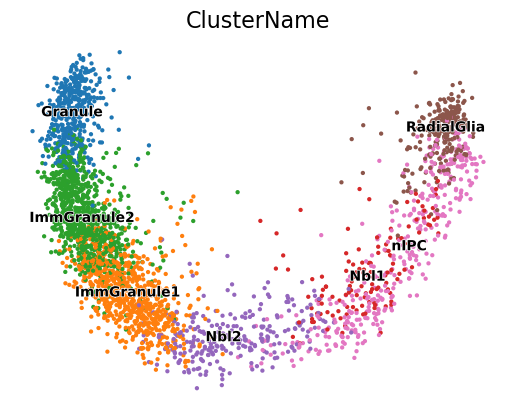

In [14]:
clusters = adata0.obs['ClusterName']
scv.pl.scatter(adata0, color="ClusterName",basis='pca', fontsize=16, save=result_path+'clusters.png')

In [15]:
scv.pp.pca(adata0,n_comps=50)

## ------data preprocessing: single run
scv.pp.neighbors(adata0, n_neighbors=k_nei)
scv.pp.moments(adata0, n_pcs=50, n_neighbors=k_nei)

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [16]:
gene_arr=adata0.var.index.values
X_pca=adata0.obsm['X_pca']
# cell_vpt=adata0.obs['velocity_pseudotime'].values#cell_vpt = adata0.obs['latent_time'].values#
cell_vpt=adata0.obs['palantir_pseudotime'].values
color_label = cell_vpt
Xs=adata0.layers['Ms']#adata.X.A#
X_pca.shape

(3139, 50)

In [17]:
cell_nei=adata0.uns['neighbors']['indices']
def Nei_matrices(cell_nei,k_nei,adata):    
    row =np.array([np.ones((k_nei,))*i for i in range(adata.shape[0])]).flatten()
    col=cell_nei.flatten()
    w_val=np.array([np.linalg.norm(X_pca[int(i),:]-X_pca[int(j),:]) for i,j in zip(row,col)])
    adj_val=np.ones(col.shape)
    dc=np.amax(w_val)
    nei_w=[]
    rho_arr=[]
    for i in range(cell_nei.shape[0]):
        dij=np.array([np.linalg.norm(X_pca[i,:]-X_pca[int(j),:]) for j in cell_nei[i]])
        rho=np.sum(np.exp(-dij**2/dc**2))
        nei_w.append(np.exp(-dij**2/dc**2)/rho)
        rho_arr.append(rho)
    rho_arr=np.array(rho_arr)/np.amax(rho_arr)
    nei_w=np.array(nei_w)
    A_mat=csr_matrix((adj_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
    W_mat=csr_matrix((w_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
    Nei_mat=csr_matrix((nei_w.flatten(), (row, col)), shape=(adata.shape[0], adata.shape[0]))
    return nei_w,A_mat,W_mat,Nei_mat
nei_w,A_mat,W_mat,Nei_mat = Nei_matrices(cell_nei,k_nei,adata0)

In [18]:
def smooth_func(X_val,cell_nei=cell_nei,nei_w=nei_w):
    X_s=X_val.copy()
    for ci in range(len(X_val)):
        X_s[ci]=np.dot(X_val[cell_nei[ci,:]],nei_w[ci,:])
    return(X_s)

In [19]:
[k_nei,K,L] = [10,2,10]
subfolder = 'junda'
read_path = 'results/'+model_name+'/'+subfolder+'/' +f'k_nei={k_nei}/K={K} L={L}'+'/'
# GE_results = np.load(read_path+'GE_results.npz',allow_pickle=True)['arr_0'].item()

In [20]:
encoder = torch.load(read_path+'encoder.pt')
X = Xs
GE_results = Get_GE_results(encoder,X,GE_eigen=None)

In [21]:
mu_learned = GE_results['mu_learned']
sigma_learned = GE_results['sigma_learned']
latent_z = GE_results['latent_z']
Fisher_g = GE_results['Fisher_g']
pMu_pX = GE_results['pMu_pX']
pSgm_pX = GE_results['pSgm_pX']

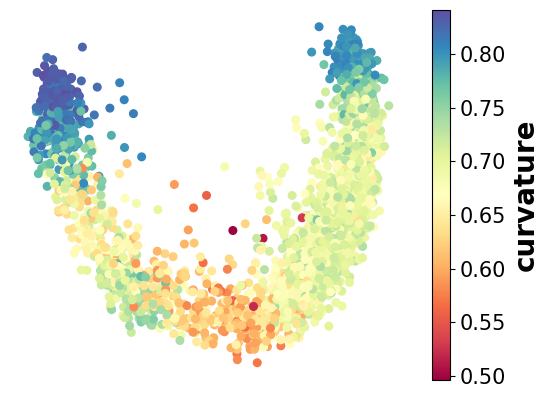

In [22]:
###
X_plt,Y_plt = -adata0.obsm['X_pca'][:,0],adata0.obsm['X_pca'][:,1]
cRc_arr=[]
cRc_arr_eu=[]
A = csr_matrix(A_mat + np.eye(A_mat.shape[0]))
for inds in np.split(A.indices, A.indptr)[1:-1]:
    self_ind=inds[0]
    cRc=0
    cRc_eu=0
    for nei_k in range(1,len(inds)):

        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dFi=Fisher_dist(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dWa=wasserstein_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])

        cRc+=1-dWa/dFi
        cRc_eu+=1-dWa/dEu

    cRc_arr.append(cRc/len(inds))
    cRc_arr_eu.append(cRc_eu/len(inds))
crc = np.array(cRc_arr)
crc_eu = np.array(cRc_arr_eu)
crc_smooth = smooth_func(crc_eu)

idx = ~np.isnan(crc_smooth)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)


In [23]:
A = csr_matrix(A_mat + np.eye(A_mat.shape[0]))
cRc_arr=[]
cRc_arr_eu=[]
cRc_arr_eu1=[]
for inds in np.split(A.indices, A.indptr)[1:-1]:
    self_ind=inds[0]
    cRc=0
    cRc_eu=0
    cRc_eu1=0
    for nei_k in range(1,len(inds)):
        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dEu1 = np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:],ord=1)
        dWa1 = W1_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dFi=Fisher_dist(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dWa=wasserstein_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        cRc+=1-dWa/dFi
        cRc_eu+=1-dWa/dEu
        cRc_eu1+=1-dWa1/dEu1
    
    cRc_arr.append(cRc/len(inds))
    cRc_arr_eu.append(cRc_eu/len(inds))
    cRc_arr_eu1.append(cRc_eu1/len(inds))

crc = np.array(cRc_arr)
crc_eu = np.array(cRc_arr_eu)
crc_smooth = smooth_func(crc_eu)
crc_eu1 = np.array(cRc_arr_eu1)
crc_smooth1 = smooth_func(crc_eu1)


In [24]:
print(np.corrcoef(crc_smooth,crc_smooth1)[0,1])

0.9638883821810755


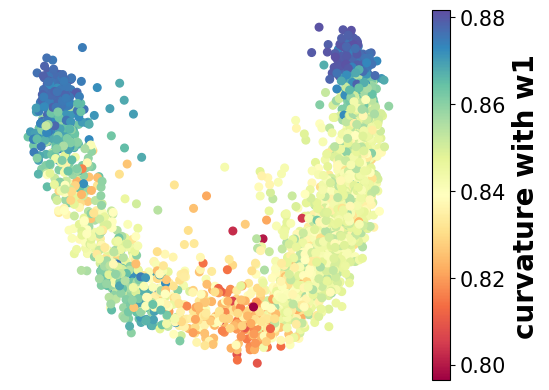

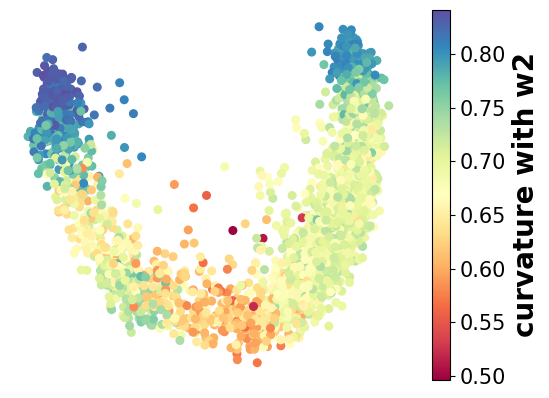

In [25]:
idx = ~np.isnan(crc_smooth1)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth1[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature with w1',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)
plt.savefig(f'results/curvature/{data_name}_curvature_w1.png',dpi=600)
plt.show()

idx = ~np.isnan(crc_smooth)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature with w2',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)
plt.savefig(f'results/curvature/{data_name}_curvature_w2.png',dpi=600)
plt.show()

### EG

In [26]:
data_path='data/'
#data_name = 'BoneMarrow/human_cd34_bone_marrow.h5ad'
#data_name = 'EG_ab_dyn.h5ad'
data_name = 'EG_ab_bin.h5ad'
#data_name = 'processed bonemarrow.h5ad'
#data_name = 'lung.h5ad'
#data_name = 'DentateGyrus/DentateGyrus.loom'
adata0=scv.read(data_path+data_name, cache=True)

model_name = 'EG_ab_bin'

subfolder = 'Adjacency'
result_path = 'results/'+model_name+'/'+subfolder+'/'

[k_nei,K,L] = [10,3,6]

import os
folder = os.path.exists(result_path)
if not folder:                   #判断是否存在文件夹如果不存在则创建为文件夹
    os.makedirs(result_path)


In [27]:
scv.pp.pca(adata0,n_comps=50)

## ------data preprocessing: single run

scv.pp.neighbors(adata0, n_neighbors=k_nei)
scv.pp.moments(adata0, n_pcs=50, n_neighbors=k_nei)

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [28]:
scv.tl.velocity(adata0)
# scv.tl.velocity_graph(adata0)
# scv.tl.velocity_pseudotime(adata0)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


d:\Anaconda\envs\pytorch\Lib\site-packages\scvelo\tools\optimization.py:173: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


In [29]:
gene_arr=adata0.var.index.values
X_pca=adata0.obsm['X_pca']
# cell_vpt=adata0.obs['velocity_pseudotime'].values#cell_vpt = adata0.obs['latent_time'].values#
cell_vpt=adata0.obs['palantir_pseudotime'].values
color_label = cell_vpt
Xs=adata0.layers['Ms']#adata.X.A#
X_pca.shape

cell_nei=adata0.uns['neighbors']['indices']
def Nei_matrices(cell_nei,k_nei,adata):    
    row =np.array([np.ones((k_nei,))*i for i in range(adata.shape[0])]).flatten()
    col=cell_nei.flatten()
    w_val=np.array([np.linalg.norm(X_pca[int(i),:]-X_pca[int(j),:]) for i,j in zip(row,col)])
    adj_val=np.ones(col.shape)
    dc=np.amax(w_val)
    nei_w=[]
    rho_arr=[]
    for i in range(cell_nei.shape[0]):
        dij=np.array([np.linalg.norm(X_pca[i,:]-X_pca[int(j),:]) for j in cell_nei[i]])
        rho=np.sum(np.exp(-dij**2/dc**2))
        nei_w.append(np.exp(-dij**2/dc**2)/rho)
        rho_arr.append(rho)
    rho_arr=np.array(rho_arr)/np.amax(rho_arr)
    nei_w=np.array(nei_w)
    A_mat=csr_matrix((adj_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
    W_mat=csr_matrix((w_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
    Nei_mat=csr_matrix((nei_w.flatten(), (row, col)), shape=(adata.shape[0], adata.shape[0]))
    return nei_w,A_mat,W_mat,Nei_mat
nei_w,A_mat,W_mat,Nei_mat = Nei_matrices(cell_nei,k_nei,adata0)

def smooth_func(X_val,cell_nei=cell_nei,nei_w=nei_w):
    X_s=X_val.copy()
    for ci in range(len(X_val)):
        X_s[ci]=np.dot(X_val[cell_nei[ci,:]],nei_w[ci,:])
    return(X_s)

In [30]:
[k_nei,K,L] = [10,3,6]
subfolder = 'Adjacency'
read_path = 'results/'+model_name+'/'+subfolder+'/' +f'k_nei={k_nei}/K={K} L={L}'+'/'
# GE_results = np.load(read_path+'GE_results.npz',allow_pickle=True)['arr_0'].item()

In [31]:
encoder = torch.load(read_path+'encoder.pt')
X = Xs
GE_results = Get_GE_results(encoder,X,GE_eigen=None)

In [32]:
mu_learned = GE_results['mu_learned']
sigma_learned = GE_results['sigma_learned']
latent_z = GE_results['latent_z']
Fisher_g = GE_results['Fisher_g']
pMu_pX = GE_results['pMu_pX']
pSgm_pX = GE_results['pSgm_pX']
X_plt,Y_plt = adata0.obsm['X_umap'][:,0],adata0.obsm['X_umap'][:,1]

0.8940077840907601


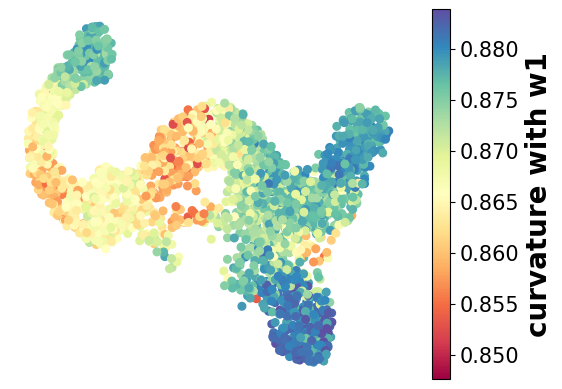

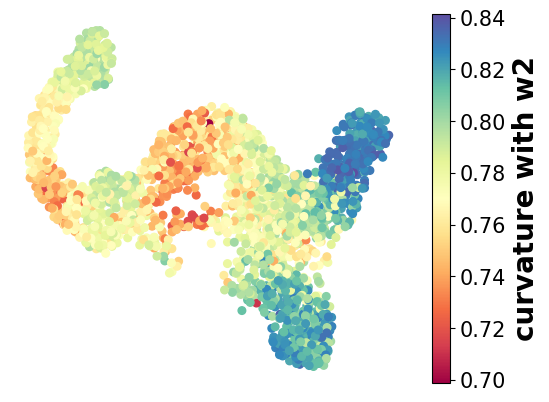

In [33]:
A = csr_matrix(A_mat + np.eye(A_mat.shape[0]))
cRc_arr=[]
cRc_arr_eu=[]
cRc_arr_eu1=[]
for inds in np.split(A.indices, A.indptr)[1:-1]:
    self_ind=inds[0]
    cRc=0
    cRc_eu=0
    cRc_eu1=0
    for nei_k in range(1,len(inds)):
        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dEu1 = np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:],ord=1)
        dWa1 = W1_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dFi=Fisher_dist(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        dWa=wasserstein_distance(mu_learned[self_ind,:],sigma_learned[self_ind,:],\
                        mu_learned[inds[nei_k],:],sigma_learned[inds[nei_k],:])
        cRc+=1-dWa/dFi
        cRc_eu+=1-dWa/dEu
        cRc_eu1+=1-dWa1/dEu1
    
    cRc_arr.append(cRc/len(inds))
    cRc_arr_eu.append(cRc_eu/len(inds))
    cRc_arr_eu1.append(cRc_eu1/len(inds))

crc = np.array(cRc_arr)
crc_eu = np.array(cRc_arr_eu)
crc_smooth = smooth_func(crc_eu)
crc_eu1 = np.array(cRc_arr_eu1)
crc_smooth1 = smooth_func(crc_eu1)
print(np.corrcoef(crc_smooth,crc_smooth1)[0,1])

idx = ~np.isnan(crc_smooth1)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth1[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature with w1',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)
plt.savefig(f'results/curvature/{data_name}_curvature_w1.png',dpi=600)
plt.show()

idx = ~np.isnan(crc_smooth)
cmap = plt.colormaps['Spectral']
plt.scatter(X_plt[idx],Y_plt[idx],c=crc_smooth[idx],s=30,cmap=cmap)
plt.axis('off')
clb=plt.colorbar()
clb.ax.set_ylabel('curvature with w2',fontsize=20,weight='bold')
clb.ax.tick_params(axis='y', labelsize=15)
plt.savefig(f'results/curvature/{data_name}_curvature_w2.png',dpi=600)
plt.show()